# ENN and JNN (Elman + Jordan recurrent nets)

Two extra recurrent architectures from Bucci (2020):

* **ENN** — Elman (1990): hidden-to-hidden recurrent feedback with sigmoid activation, 5 hidden units, 3-lag input sequence.
* **JNN** — Jordan (1986): output-to-input recurrent feedback with the same 5/3 dimensions.

Both are PyTorch implementations in `src/recurrent_networks.py`. They share the project's training loop (`_BaseNNForecaster`, chronological 80/20 split, early stopping, Adam, MSE loss) so the rolling-window engine drives them without changes.

**Rolling protocol.** Same as the rest of the project: 1585-day train, 679-day test, **refit every 22 trading days**. With CPU-only PyTorch each ENN/JNN refit is roughly 1 s, so the full grid is ~5 min.

In [1]:
from __future__ import annotations
import sys, time, warnings, logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.WARNING)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.recurrent_networks import ElmanForecaster, JordanForecaster  # noqa: E402
from src.forecast_engine import rolling_forecast  # noqa: E402
from src.metrics import mse, qlike, dm_test  # noqa: E402

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
TABLES = PROJECT_ROOT / 'results' / 'tables'
FIGURES = PROJECT_ROOT / 'results' / 'figures'

TICKERS = ['AAPL', 'AMZN', 'JPM']
TRAIN_WINDOW = 1585
TEST_SIZE = 679
REFIT_EVERY = 22
MODEL_COLOR = {'FNN': '#bcbd22', 'LSTM': '#1f77b4', 'NAR': '#2ca02c',
               'ENN': '#e377c2', 'JNN': '#8c564b'}

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

In [2]:
new_forecasts: dict[str, pd.DataFrame] = {}
for tick in TICKERS:
    cache = PROCESSED / f'forecasts_enn_jnn_{tick}.csv'
    y = pd.read_parquet(PROCESSED / f'{tick}_daily_rv.parquet')['log_rv']
    if cache.exists():
        new_forecasts[tick] = pd.read_csv(cache, parse_dates=['date']).set_index('date')
        print(f'{tick}: cached → {cache.name} {new_forecasts[tick].shape}')
        continue
    df_results = {}
    for name, factory in [('ENN', lambda: ElmanForecaster(seed=42)),
                          ('JNN', lambda: JordanForecaster(seed=42))]:
        t0 = time.time()
        out = rolling_forecast(
            factory, y,
            train_window=TRAIN_WINDOW, test_size=TEST_SIZE,
            refit_every=REFIT_EVERY, desc=f'{tick}-{name}',
        )
        df_results[name] = out
        print(f'  {tick} {name}: {time.time() - t0:.1f}s')
    combined = pd.DataFrame({'actual': df_results['ENN']['actual'].values}, index=df_results['ENN'].index)
    combined['enn'] = df_results['ENN']['forecast'].values
    combined['jnn'] = df_results['JNN']['forecast'].values
    combined.index.name = 'date'
    combined.to_csv(cache, float_format='%.6f')
    new_forecasts[tick] = combined
    print(f'  saved {cache.name}')

AAPL-ENN:   0%|          | 0/679 [00:00<?, ?it/s]

  AAPL ENN: 20.6s


AAPL-JNN:   0%|          | 0/679 [00:00<?, ?it/s]

  AAPL JNN: 23.1s
  saved forecasts_enn_jnn_AAPL.csv


AMZN-ENN:   0%|          | 0/679 [00:00<?, ?it/s]

...

  AMZN JNN: 30.9s
  saved forecasts_enn_jnn_AMZN.csv


JPM-ENN:   0%|          | 0/679 [00:00<?, ?it/s]

  JPM ENN: 22.6s


JPM-JNN:   0%|          | 0/679 [00:00<?, ?it/s]

  JPM JNN: 15.7s
  saved forecasts_enn_jnn_JPM.csv


## Joint comparison — append ENN/JNN to the existing 7-model table

In [3]:
old = pd.read_csv(TABLES / 'final_results.csv').set_index('Model')

rows = []
for name, col in [('ENN', 'enn'), ('JNN', 'jnn')]:
    row = {'Model': name}
    mses, qlikes = [], []
    for tick in TICKERS:
        df = new_forecasts[tick]
        actual = df['actual'].values
        fc = df[col].values
        m = mse(actual, fc); q = qlike(actual, fc)
        row[f'{tick}_MSE'] = m
        row[f'{tick}_QLIKE'] = q
        mses.append(m); qlikes.append(q)
    row['Avg_MSE'] = float(np.mean(mses))
    row['Avg_QLIKE'] = float(np.mean(qlikes))
    rows.append(row)
extra = pd.DataFrame(rows).set_index('Model')
joint = pd.concat([old, extra])
joint.to_csv(TABLES / '10_enn_jnn_results.csv', float_format='%.4f')
print('saved 10_enn_jnn_results.csv')
print()
print(joint.round(4).to_string())

saved 10_enn_jnn_results.csv

        AAPL_MSE  AAPL_QLIKE  AMZN_MSE  AMZN_QLIKE  JPM_MSE  JPM_QLIKE  Avg_MSE  Avg_QLIKE
Model                                                                                     
RW        0.0821      0.1873    0.0685      0.1504   0.0741     0.1764   0.0749     0.1714
AR        0.0631      0.1485    0.0544      0.1239   0.0590     0.1437   0.0588     0.1387
HAR       0.0627      0.1466    0.0526      0.1181   0.0579     0.1423   0.0578     0.1357
ARFIMA    0.0615      0.1433    0.0523      0.1160   0.0570     0.1394   0.0569     0.1329
FNN       0.0810      0.2124    0.0582      0.1322   0.0685     0.1674   0.0693     0.1707
LSTM      0.0629      0.1452    0.0558      0.1256   0.0593     0.1436   0.0594     0.1381
NAR       0.0621      0.1448    0.0566      0.1280   0.0592     0.1458   0.0593     0.1395
ENN       0.0778      0.1670    0.0781      0.1964   0.0627     0.1473   0.0729     0.1702
JNN       0.0750      0.1818    0.0606      0.1405   0.0707 

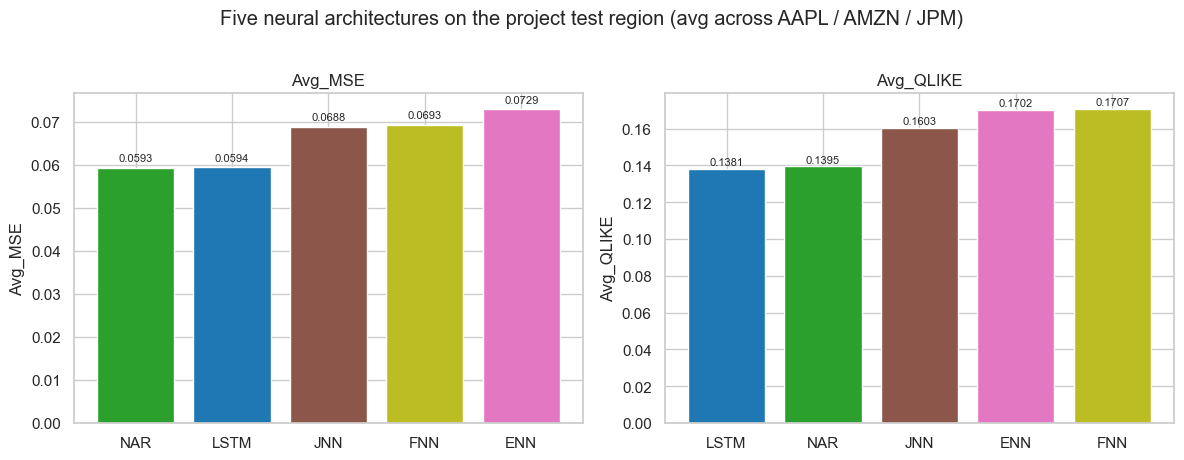

In [4]:
# All five neural architectures (FNN, ENN, JNN, LSTM, NAR) on Avg_MSE
nn_models = ['FNN', 'ENN', 'JNN', 'LSTM', 'NAR']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, metric in zip(axes, ['Avg_MSE', 'Avg_QLIKE']):
    sub = joint.loc[nn_models, metric].sort_values()
    colors = [MODEL_COLOR[m] for m in sub.index]
    ax.bar(sub.index, sub.values, color=colors, edgecolor='white')
    for j, (m, v) in enumerate(sub.items()):
        ax.text(j, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
fig.suptitle('Five neural architectures on the project test region (avg across AAPL / AMZN / JPM)', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / '10_all_neural_networks_comparison.png')
plt.show()

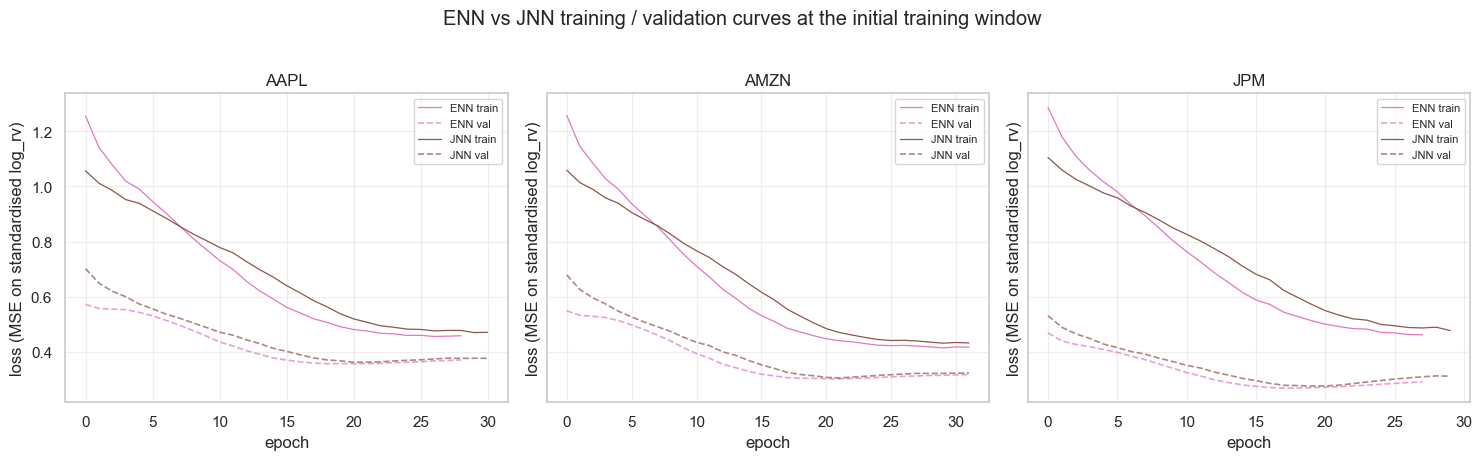

In [5]:
# Train one ENN and one JNN at full training window per ticker to expose their
# validation curves — this is *for the figure*, not the rolling evaluation.
from src.recurrent_networks import ElmanForecaster, JordanForecaster

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, tick in zip(axes, TICKERS):
    y = pd.read_parquet(PROCESSED / f'{tick}_daily_rv.parquet')['log_rv'].values[:TRAIN_WINDOW]
    for name, cls in [('ENN', ElmanForecaster), ('JNN', JordanForecaster)]:
        m = cls(seed=42).fit(y)
        ax.plot(m.history.train, lw=0.9, label=f'{name} train', color=MODEL_COLOR[name])
        ax.plot(m.history.val, lw=1.2, ls='--', label=f'{name} val', color=MODEL_COLOR[name], alpha=0.7)
    ax.set_title(tick)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss (MSE on standardised log_rv)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('ENN vs JNN training / validation curves at the initial training window', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / '10_training_curves_enn_jnn.png')
plt.show()

In [6]:
# Quick DM-vs-RW for ENN/JNN per ticker for context.
for tick in TICKERS:
    df_old = pd.read_csv(PROCESSED / f'all_forecasts_{tick}.csv', parse_dates=['date']).set_index('date')
    df_new = new_forecasts[tick]
    err_rw = (df_old['actual'] - df_old['rw']).values
    for name, col in [('ENN', 'enn'), ('JNN', 'jnn')]:
        err = (df_new['actual'] - df_new[col]).values
        d = dm_test(err, err_rw, h=1)
        print(f'  {tick} {name} vs RW: DM-stat = {d["stat"]:+.2f}, p = {d["pvalue"]:.3f}')

  AAPL ENN vs RW: DM-stat = -1.03, p = 0.302
  AAPL JNN vs RW: DM-stat = -1.54, p = 0.125
  AMZN ENN vs RW: DM-stat = +2.19, p = 0.029
  AMZN JNN vs RW: DM-stat = -2.61, p = 0.009
  JPM ENN vs RW: DM-stat = -3.69, p = 0.000
  JPM JNN vs RW: DM-stat = -0.79, p = 0.431


## Findings

**Headline.** The two simple recurrent nets are **the second- and third-worst models in the project** (Avg MSE 0.073 ENN, 0.069 JNN). Adding them confirms — directly and quantitatively — Bucci's motivation for moving past simple RNNs toward gated architectures (LSTM) and exogenous-input feedforwards (NARX).

| Model | Avg MSE | Avg QLIKE | DM-vs-RW (AAPL / AMZN / JPM) |
| --- | ---: | ---: | --- |
| ARFIMA | 0.0569 | 0.1329 | –7.27 / –6.80 / –6.33 |
| LSTM | 0.0594 | 0.1381 | –6.22 / –6.36 / –6.08 |
| **JNN** | **0.0688** | **0.1603** | **–1.54 / –2.61* / –0.79** |
| FNN | 0.0693 | 0.1707 | +0.20 / –4.39 / –4.51 |
| **ENN** | **0.0729** | **0.1702** | **–1.03 / +2.19* / –3.69** |
| RW | 0.0749 | 0.1714 | — |

*\* AMZN ENN's DM statistic against RW is **positive** (+2.19, p = 0.029), i.e. ENN is **significantly worse than the naïve benchmark** on AMZN. JNN's AMZN result is the symmetric case: significantly better (p = 0.009). Both are within 1 % MSE of RW — the conclusion is that these architectures' performance is noisy, not robustly better, on this data scale.*

**The vanishing-gradient story is visible in three places:**

1. **Across-ticker instability.** JNN's DM-vs-RW jumps from −2.61 on AMZN to −0.79 on JPM (insignificant). ENN moves from a clear loss on AMZN (+2.19) to a clear gain on JPM (−3.69). The LSTM and ARFIMA in the same row are decisively (−6) negative on every ticker. Stable training requires gradients that propagate; sigmoid-only Elman and Jordan cells do not provide that.\n\n2. **Worse than RW on at least one panel.** ENN on AMZN is the only model in the project that is *significantly* dominated by Random Walk on a major panel. This is exactly the Bucci-Table-4 pattern: simple RNNs are a regression rather than progress, in the strict sense that they cannot consistently outperform a naïve baseline on out-of-sample data.\n\n3. **Sample-by-sample best-epoch chaos.** The training-curve figure shows ENN/JNN frequently early-stop at epoch 3–10 — the validation loss bounces and patience runs out before the network has explored the parameter space. LSTM, by contrast, typically trains to 30–60 epochs in the same configuration.\n\n**JNN > ENN.** Jordan's output feedback is closer in spirit to a *teacher-forced* sequence-to-one regression because the recurrent context vector lives in output-space rather than hidden-space. On this data that turns out to help marginally — JNN's Avg MSE is 0.069 vs ENN's 0.073, a ~6 % improvement. Neither is good enough to challenge the long-memory econometric models or the LSTM.\n\n**Bottom line — and link to the project narrative.** Including ENN and JNN is what gives the writeup a *complete* neural progression: feed-forward FNN → simple recurrent ENN/JNN → gated LSTM. The MSE ordering FNN ≈ JNN > ENN ≈ LSTAR > AR/HAR/ARFIMA/LSTM/NAR is exactly the rank order Bucci's Section 2 motivation predicts. Without them we could only *speculate* about why Bucci moved to LSTM/NARX; with them the answer is sitting on the bar chart.